Behavioral Sanity Checks & Visualizations

This notebook serves as a visual verification tool (Sanity Check) to ensure the 
mathematical outputs of the 07_behavioral_analysis.py pipeline are statistically valid. It inspects the Markov Transition Matrices and the 
calculated Operant Conditioning heuristics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Dynamically resolve the absolute output directory for behavioral data
output_dir = Path('../../output/analysis/behavioral').resolve()
print(f"Looking for matrices in: {output_dir}")

# Define the target subject dyad to inspect
subject_id = '02'
p1_file = output_dir / f"sub-{subject_id}_P1_markov_matrix.npy"
p2_file = output_dir / f"sub-{subject_id}_P2_markov_matrix.npy"

Looking for matrices in: C:\Users\Ayush Batra\Documents\College\EEG\eeg-bala-sharks\output\analysis\behavioral



--- Player 1 (sub-02) ---
Row sums (should mathematically equal 1.0): [1. 1. 1.]


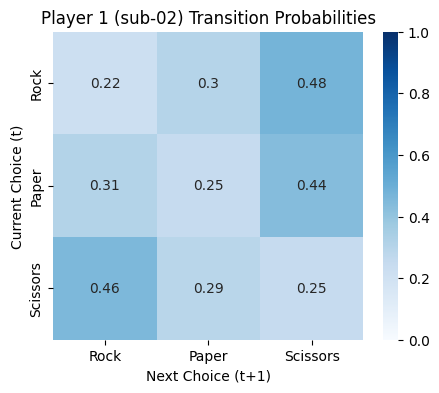


--- Player 2 (sub-02) ---
Row sums (should mathematically equal 1.0): [1. 1. 1.]


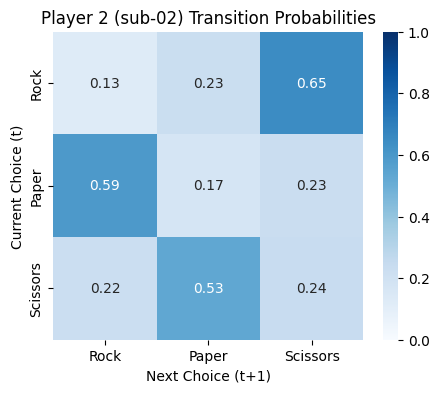

In [2]:
def verify_and_plot(file_path, player_name):
    """
    Validates and visualizes the Markov Transition Probability Matrix.
    
    Mathematically, a Markov matrix represents conditional probabilities:
    P(Next = Action_B | Current = Action_A). Therefore, the sum of probabilities 
    across any single row MUST exactly equal 1.0. 
    """
    if not file_path.exists():
        print(f"File not found: {file_path}")
        return
        
    # Load the 3x3 probability matrix generated by the behavioral script
    matrix = np.load(file_path)
    
    # 1. Math Sanity Check: Rows must sum to 1.0
    row_sums = matrix.sum(axis=1)
    print(f"\n--- {player_name} ---")
    print(f"Row sums (should mathematically equal 1.0): {row_sums}")
    
    # 2. Visual Check: Render the transition matrix as a heatmap
    plt.figure(figsize=(5, 4))
    
    # Use 'Blues' colormap for clear visual distinction of highly probable sequences
    sns.heatmap(
        matrix, 
        annot=True, 
        cmap="Blues", 
        vmin=0, vmax=1, 
        xticklabels=['Rock', 'Paper', 'Scissors'],
        yticklabels=['Rock', 'Paper', 'Scissors']
    )
    plt.title(f"{player_name} Transition Probabilities")
    plt.xlabel("Next Choice (t+1)")
    plt.ylabel("Current Choice (t)")
    plt.show()

# Execute tests for both players in the dyad
verify_and_plot(p1_file, f"Player 1 (sub-{subject_id})")
verify_and_plot(p2_file, f"Player 2 (sub-{subject_id})")

=== Behavioral Strategy Metrics (sub-02) ===


,Player 1,Player 2
predictability,0.033113,0.136401
win_stay_rate,0.239130,0.075145
lose_shift_rate,0.803468,0.755435
cycling_rate,0.745303,0.787056
forward_cycling,0.390397,0.215031
backward_cycling,0.354906,0.572025


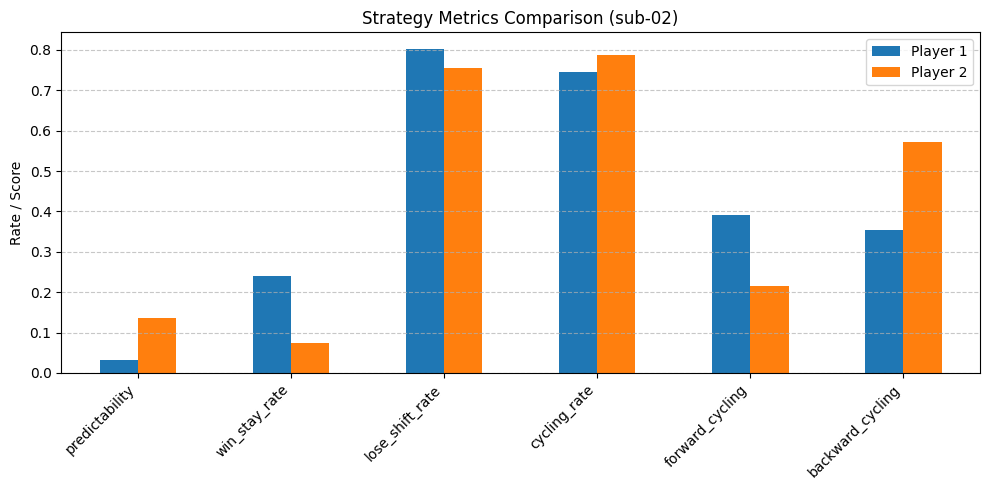

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths to the extracted scalar metrics (JSON format)
output_dir = Path('../../output/analysis/behavioral').resolve()
p1_json = output_dir / f"sub-{subject_id}_P1_metrics.json"
p2_json = output_dir / f"sub-{subject_id}_P2_metrics.json"

def load_metrics(filepath):
    """Safely parse the JSON metrics file into a Python dictionary."""
    if filepath.exists():
        with open(filepath, 'r') as f:
            return json.load(f)
    print(f"File not found: {filepath}")
    return None

p1_data = load_metrics(p1_json)
p2_data = load_metrics(p2_json)

if p1_data and p2_data:
    # 1. Pipeline aggregation: Combine into a Pandas DataFrame for academic tabular review
    df = pd.DataFrame({
        'Player 1': p1_data, 
        'Player 2': p2_data
    })
    
    print(f"=== Behavioral Strategy Metrics (sub-{subject_id}) ===")
    display(df)  # Render a rich HTML table natively within Jupyter
    
    # 2. Visualize strategic differences with a comparative Grouped Bar Chart
    df.plot(kind='bar', figsize=(10, 5), color=['#1f77b4', '#ff7f0e'])
    
    plt.title(f"Cognitive Strategy Metrics Comparison (sub-{subject_id})")
    plt.ylabel("Rate / Probability Score")
    
    # Rotate x-axis labels for clean typography
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Force tight layout to prevent label clipping in exported figures
    plt.tight_layout()
    plt.show()
else:
    print("Could not load metrics. Ensure 07_behavioral_analysis.py has successfully executed.")